In [ ]:
import geopandas as gpd
from project_paths import paths


In [ ]:
gdf_aims = gpd.read_file(paths.aims_data / "AIMS_Spatial_Flood_Defences_inc_standardised_attributes.geojson")

print(gdf_aims.head())


In [4]:
gdf_aims.describe()

,asset_length,toe_level,current_sop,design_sop,design_ucl,year_last_refurbished,actual_dcl,actual_ucl,design_dcl,effective_cl
count,141993.000000,2660.000000,4696.000000,116479.000000,11055.000000,1038.000000,74670.000000,74492.000000,12572.000000,20092.000000
mean,414.089448,4.099453,286.174830,76.547549,22.917466,2012.736994,39.876478,40.033323,24.667833,19.286604
std,793.500401,9.080826,623.906862,228.633890,35.482221,7.330285,47.797064,47.560088,194.061702,28.793228
min,0.010000,-3.000000,0.000000,0.000000,0.000000,1948.000000,-1.000000,-1.000000,-9999.000000,-0.200000
25%,41.869999,1.842250,50.000000,5.000000,5.280000,2011.000000,6.080000,6.160000,5.230000,4.260000
50%,144.230000,2.851000,100.000000,5.000000,6.900000,2014.000000,19.837499,20.100000,6.800000,6.380000
75%,441.500000,4.300000,200.000000,50.000000,26.000000,2017.000000,57.150002,57.641749,26.680000,20.020250
max,24196.820000,223.000000,10000.000000,9999.000000,276.399990,2024.000000,297.609990,292.260010,18900.000000,284.954990


In [ ]:
gdf_aims_alt = gpd.read_file(paths.aims_data / "aims.gpkg")

print(gdf_aims_alt.head())

In [ ]:
gdf_camel_catchments = gpd.read_file(paths.camels_data / "camels_gb_v2_catchment_boundaries.shp")

print(gdf_camel_catchments.head())


In [ ]:
gdf_camel_catchments = gpd.read_file(paths.camels_data / "camels_gb_v2_catchment_boundaries.shx")

print(gdf_camel_catchments.head())

annoying that the catchment/gauge id isnt in the shape file...

the coordinates of each gauge is in the topographical attributes file. There is one gauge per catchment, and coordinates for each gauge. Hopefully each gauge is within the catchement polygon and can be joined using a "within" spatial join where the coordinates or used to form a point. 

In [ ]:
import shapely


gdf_camels_top = gpd.read_file(paths.camels_data / "camels_gb_v2_topographic_attributes.csv")

points = [shapely.Point(row["gauge_lat"], row["gauge_lon"]) for _, row in gdf_camels_top.iterrows()]

print(points)

In [9]:
gdf_camels_top["point"] = gpd.GeoSeries(  [shapely.Point(row["gauge_lat"], row["gauge_lon"]) for _, row in gdf_camels_top.iterrows()]  )

gdf_camels_top.head()

,gauge_id,gauge_name,gauge_lat,gauge_lon,gauge_easting,gauge_northing,gauge_elev,area,dpsbar,elev_mean,elev_min,elev_10,elev_50,elev_90,elev_max,point
0,10002,Ugie at Inverugie,57.53,-1.83,410113,848516,8.50,325.72,42.30,87,9.50,38.60,84.10,140.10,233.70,POINT (57.53 -1.83)
1,10003,Ythan at Ellon,57.36,-2.09,394684,830370,3.80,532.29,55.10,108,3.50,54.10,106.10,160.80,380.40,POINT (57.36 -2.09)
2,1001,Wick at Tarroul,58.48,-3.27,326202,954915,13.00,158.18,29.90,80,12.90,30.60,78.80,135.20,241.40,POINT (58.48 -3.27)
3,101002,Medina at Shide,50.69,-1.29,450359,88113,10.40,30.61,80.00,60,9.40,26.80,56.80,98.00,193.20,POINT (50.69 -1.29)
4,101005,Eastern Yar at Budbridge,50.65,-1.25,453120,83520,17.20,24.31,87.00,92,17.20,32.90,84.00,157.20,234.60,POINT (50.65 -1.25)


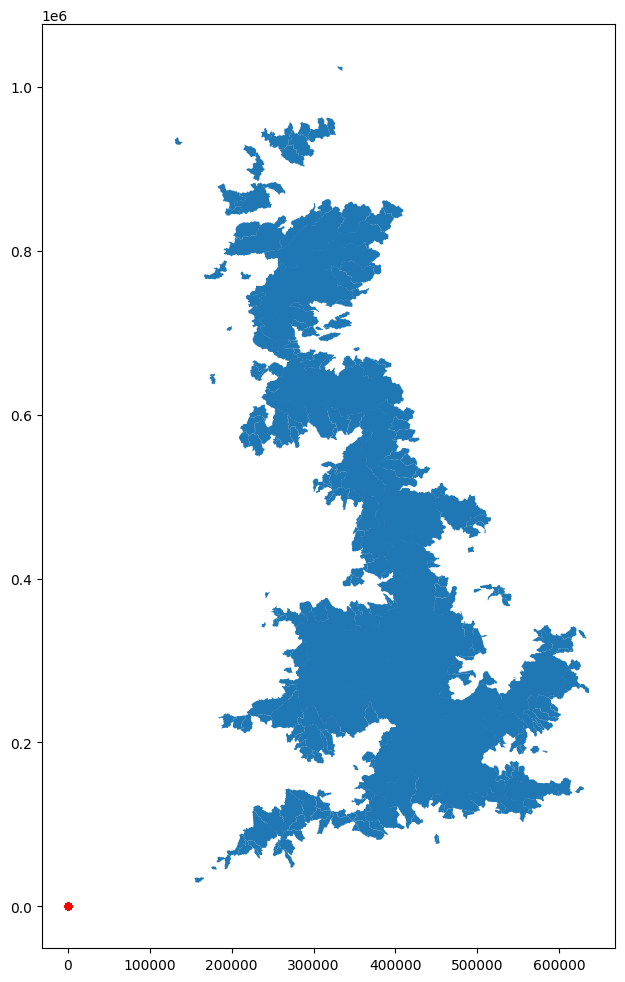

In [10]:
import matplotlib.pyplot as plt 


fig = plt.figure(figsize=(12,12))

ax = fig.add_subplot()

gdf_camel_catchments.plot(ax=ax)

gpd.GeoDataFrame(points, columns=["Point"], geometry="Point").plot(ax=ax, color="r", markersize=20)

plt.show()

seems unlikely

check coordinate systems

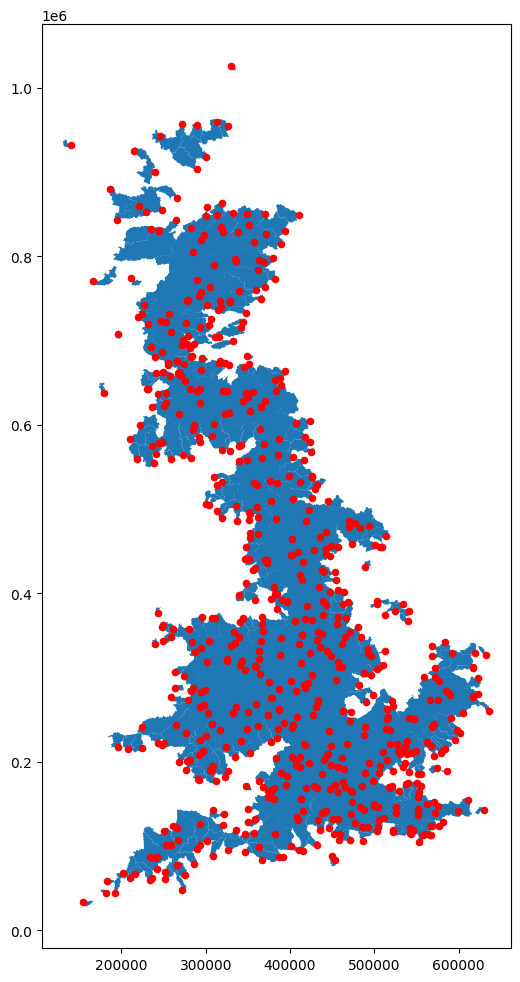

In [11]:
import matplotlib.pyplot as plt 


fig = plt.figure(figsize=(12,12))

ax = fig.add_subplot()

gdf_camel_catchments.plot(ax=ax)

other_points = [shapely.Point(row["gauge_easting"], row["gauge_northing"]) for _, row in gdf_camels_top.iterrows()]

gpd.GeoDataFrame(other_points, columns=["Point"], geometry="Point").plot(ax=ax, color="r", markersize=20)

plt.show()

not super duper helpful. I would need a massive plot to manually count how many gauges per polygon, which i dont want to do anyway

In [ ]:
gdf_camels_top = gpd.read_file(paths.camels_data / "camels_gb_v2_topographic_attributes.csv")
print(type(gdf_camels_top))

gdf_camels_top = gpd.GeoDataFrame(data=gdf_camels_top)
print(type(gdf_camels_top))

gdf_camels_top["point"] = gpd.GeoSeries(  [shapely.Point(row["gauge_easting"], row["gauge_northing"]) for _, row in gdf_camels_top.iterrows()]  )
gdf_camels_top.set_geometry("point", inplace=True)
gdf_camels_top.set_crs(crs="EPSG:27700", inplace=True)

print(type(gdf_camels_top))

gdf_camel_catchments.set_geometry("geometry", inplace=True)
gdf_camel_catchments.set_crs("EPSG:27700", inplace=True)

gdf_joined = gpd.sjoin(
    left_df=gdf_camels_top,
    right_df=gdf_camel_catchments,
    predicate="within"
)

gdf_joined.head()

In [13]:
gdf_joined.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1282 entries, 1 to 670
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   gauge_id        1282 non-null   str     
 1   gauge_name      1282 non-null   str     
 2   gauge_lat       1282 non-null   str     
 3   gauge_lon       1282 non-null   str     
 4   gauge_easting   1282 non-null   str     
 5   gauge_northing  1282 non-null   str     
 6   gauge_elev      1282 non-null   str     
 7   area            1282 non-null   str     
 8   dpsbar          1282 non-null   str     
 9   elev_mean       1282 non-null   str     
 10  elev_min        1282 non-null   str     
 11  elev_10         1282 non-null   str     
 12  elev_50         1282 non-null   str     
 13  elev_90         1282 non-null   str     
 14  elev_max        1282 non-null   str     
 15  point           1282 non-null   geometry
 16  index_right     1282 non-null   int64   
dtypes: geometry(

In [14]:
gdf_joined.describe(include=["str", "int64"])

,gauge_id,gauge_name,gauge_lat,gauge_lon,gauge_easting,gauge_northing,gauge_elev,area,dpsbar,elev_mean,elev_min,elev_10,elev_50,elev_90,elev_max,index_right
count,1282,1282,1282,1282,1282,1282,1282,1282,1282,1282,1282,1282,1282,1282,1282,1282.000000
unique,620,620,407,381,619,620,474,616,511,317,466,527,568,581,456,NaN
top,28001,Derwent at Yorkshire Bridge,52.76,-1.83,362850,385090,48.00,126.70,166.70,89,76.00,220.20,165.70,414.00,826.20,NaN
freq,7,7,14,14,10,7,11,7,13,17,11,10,9,9,27,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,322.668487
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,183.093246
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,301.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,483.000000


looks like join is broken, both fanning out and also dropping some gauges. 



In [15]:
gdf_camel_catchments = gpd.read_file("./data/camels_gb_v2_catchment_boundaries.shp")

print(gdf_camel_catchments.head())


print(gdf_camel_catchments.columns.tolist())
print(gdf_camel_catchments.crs)

                                            geometry
0  POLYGON ((326225 954900, 326225 954850, 326200...
1  POLYGON ((299875 918125, 299850 918125, 299825...
2  POLYGON ((289175 903900, 289175 903850, 288975...
3  POLYGON ((240325 900150, 240325 900050, 240375...
4  POLYGON ((248175 854650, 248175 854550, 248150...
['geometry']
None


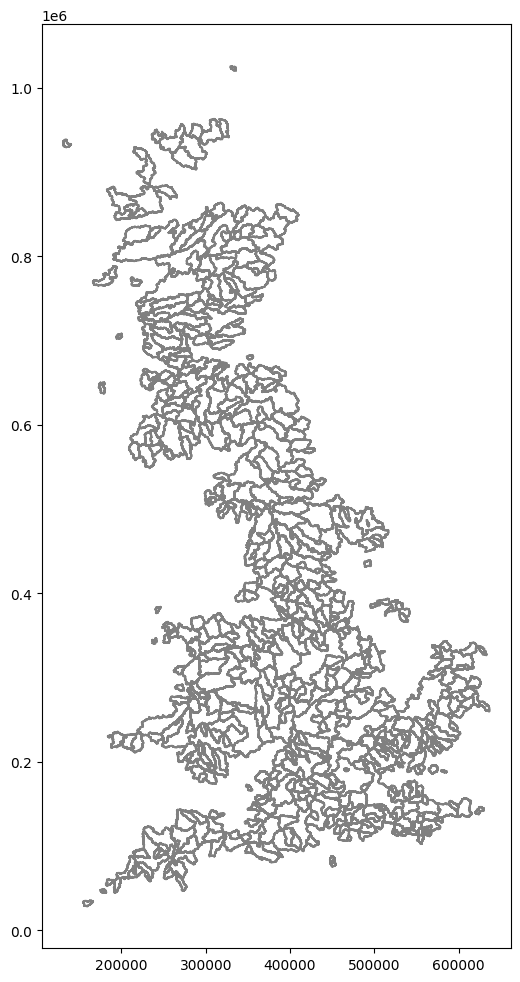

In [16]:

fig = plt.figure(figsize=(12,12))

ax = fig.add_subplot()

polygons: list[shapely.Polygon] = gdf_camel_catchments["geometry"].to_list()


outlines = [p.boundary for p in polygons]


gdf_outlines = gpd.GeoDataFrame(outlines, columns=["outlines"], geometry="outlines")

gdf_outlines.plot(ax=ax, color="grey")

plt.show()

pretty sure some of these catchemnents are enclaves. This will be why my join is fanning out, a guage joins to two catchment polygons when it is within a catchement that is within another catchment. 

In order to get one to one mapping, i could sort by area of catchment and keep the smallest one only.

But there is also another question about how we then join aims ids to this. Does a catchment being nested imply a hierarchical relationship, or can they be treated as independant?



<class 'list'>
<class 'pandas.Series'>
[<LINESTRING (326225 954900, 326225 954850, 326200 954825, 326175 954825, 326...>, <LINESTRING (299875 918125, 299850 918125, 299825 918100, 299825 918075, 299...>, <LINESTRING (289175 903900, 289175 903850, 288975 903650, 288975 903550, 288...>, <LINESTRING (240325 900150, 240325 900050, 240375 900000, 240375 899950, 240...>, <LINESTRING (248175 854650, 248175 854550, 248150 854525, 248125 854525, 248...>]
0     5
1    10
2     2
3     6
4    11
dtype: int64
  outlines  colours
0     None      NaN
1     None      NaN
2     None      NaN
3     None      NaN
4     None      NaN
                                                   0   1
0  LINESTRING (326225 954900, 326225 954850, 3262...   5
1  LINESTRING (299875 918125, 299850 918125, 2998...  10
2  LINESTRING (289175 903900, 289175 903850, 2889...   2
3  LINESTRING (240325 900150, 240325 900050, 2403...   6
4  LINESTRING (248175 854650, 248175 854550, 2481...  11
                                   

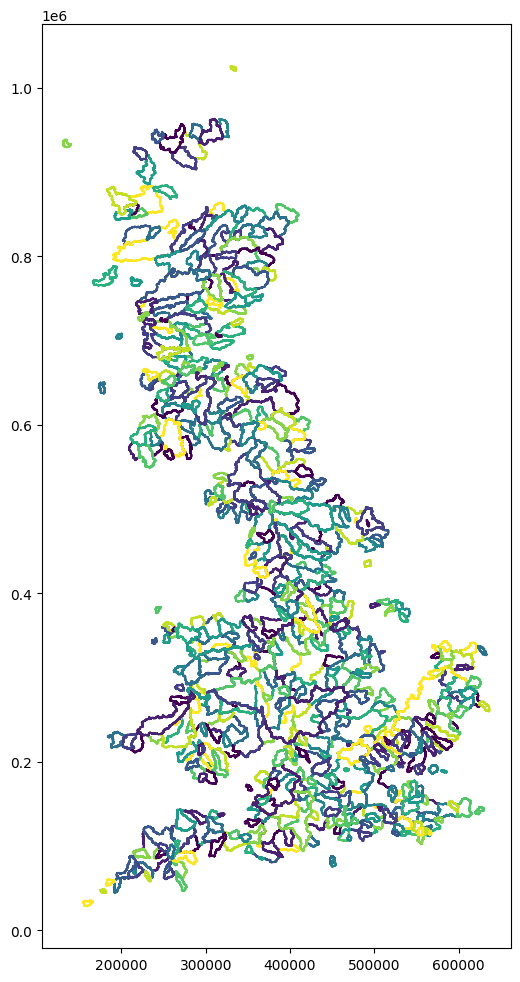

In [17]:
from mapclassify import greedy
import pandas as pd


fig = plt.figure(figsize=(12,12))

ax = fig.add_subplot()

polygons: list[shapely.Polygon] = gdf_camel_catchments["geometry"].to_list()


outlines = [p.boundary for p in polygons]

colours = greedy(gpd.GeoDataFrame(outlines, columns=["outlines"], geometry="outlines"))

# outlines = outlines.with_columns

print(type(outlines))
print(type(colours))

gdf_outlines = gpd.GeoDataFrame(pd.concat([gpd.GeoSeries(outlines),colours], axis=1), columns=["outlines","colours"], geometry="outlines")

print(outlines[0:5])
print(colours.head())
print(gdf_outlines.head())

df = pd.concat([gpd.GeoSeries(outlines),colours], axis=1)

print(df.head())

gdf = gpd.GeoDataFrame(df)

print(gdf.head())

gdf.rename(columns={0: "outline", 1: "colour"}, inplace=True)

print(gdf.head())

gdf.set_geometry("outline", inplace=True)

gdf.plot(ax=ax, column="colour")

plt.show()

so we can see that:
    1. there are some catchments that are enclaves of other catchments
    2. the uk is not fully covered by catchments

in particular, i can see that north somerset looks to be uncovered. This is a shame if it includes the somerset levels.



next steps:

1. Docs suggest that the gague id / catchment id comes from NFRA. After researching, it looks like the boundaries themselves come from NFRA. I ought to be able to get the data from NFRA with the catchment id and boundary together. It looks like this might have to be a custom request to the help desk, so i will make it now but then proceed with the next two steps in case it takes weeks:

2. Try assuming that the catchments are in exactly the same order in the attributes files and in the boundaries file. This will allow me to join on index, then verify if this worked by plotting and visually inspecting, or testing if coords of gauge are within the polygon and finding the stats for true/false

3. Try spatial joining again with two new considerations
    a. sorting by area of catchment and taking only the smallest for each gauge. This will mean that if a pump is within two catchments because one is an enclave of the other, only the innermost one will be used, avoiding fanning out the frame
    b. to handle any gauges that fall on the boundary or are just out because of resolution issue, this time i could use intersects as well as within as the join predicate, or i could use join nearest on the centroid of the boundary and the gauge coord. 



In [ ]:

catchments = gpd.read_file(paths.camels_data / 'camels_gb_v2_catchment_boundaries.shp')
catchments = catchments.set_crs('EPSG:27700')

topo = pd.read_csv(paths.camels_data / 'camels_gb_v2_topographic_attributes.csv')

assert len(catchments) == len(topo), f"Row mismatch: {len(catchments)} vs {len(topo)}"

In [20]:

catchments['area_km2'] = catchments.geometry.area / 1000000
catchments['gauge_id'] = topo['gauge_id'].values


comparison = catchments[['gauge_id','area_km2']].merge(topo[['gauge_id','area']], on='gauge_id')
comparison['pct_diff'] = abs(comparison['area_km2'] - comparison['area']) / comparison['area'] * 100
print(comparison['pct_diff'].describe())  # should be small if order matches

count      671.000000
mean       486.291718
std       1526.829861
min          0.087395
25%         53.488601
50%         86.708808
75%        212.524579
max      22558.348430
Name: pct_diff, dtype: float64


In [24]:
matching = comparison[comparison["pct_diff"] < 10]
matching.shape


(23, 4)

only 23 of the catchments have a 10 percent or less difference in the stated area and the area calculated from the boundary polygon. To me, this signals that the index joining doesn't work. 

trying spatial join again

In [ ]:
catchments = gpd.read_file(paths.camels_data / 'camels_gb_v2_catchment_boundaries.shp')
catchments = catchments.set_crs('EPSG:27700')

topo = pd.read_csv(paths.camels_data / 'camels_gb_v2_topographic_attributes.csv')

In [43]:

catchments['polygon_index'] = catchments.index


gauge_pts = gpd.GeoDataFrame(
    topo[['gauge_id', 'gauge_easting', 'gauge_northing']],
    geometry=gpd.points_from_xy(topo['gauge_easting'], topo['gauge_northing']),
    crs='EPSG:27700'
)

matched = gpd.sjoin(
    gauge_pts, 
    catchments[['polygon_index', 'area_km2', 'geometry']],
    how='left', predicate='within'
)

# where a gauge matched multiple polygons, keep the smallest. this handles nested catchments by keeping the inner one
matched = (
    matched
    .sort_values('area_km2')
    .drop_duplicates(subset='gauge_id', keep='first')
)

matched.info()



<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 671 entries, 594 to 657
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   gauge_id        671 non-null    int64   
 1   gauge_easting   671 non-null    int64   
 2   gauge_northing  671 non-null    int64   
 3   geometry        671 non-null    geometry
 4   index_right     620 non-null    float64 
 5   polygon_index   620 non-null    float64 
 6   area_km2        620 non-null    float64 
dtypes: float64(3), geometry(1), int64(3)
memory usage: 41.9 KB


In [44]:
# there are 51 right indexes that are null i.e. not joining


# 'within' could miss points exactly on the edge; use nearest for the stragglers
unmatched = matched['polygon_index'].isna()
print(unmatched.sum())


51


In [45]:


unmatched_points = gauge_pts[gauge_pts['gauge_id'].isin(
    matched.loc[unmatched, 'gauge_id']
)]

unmatched_points.head(10)


,gauge_id,gauge_easting,gauge_northing,geometry
0,10002,410113,848516,POINT (410113 848516)
5,102001,242925,376857,POINT (242925 376857)
7,107001,329532,1025280,POINT (329532 1025280)
31,15013,306715,725811,POINT (306715 725811)
49,18001,279225,705376,POINT (279225 705376)
54,18011,277658,695458,POINT (277658 695458)
76,21016,394185,663565,POINT (394185 663565)
99,25001,425923,513748,POINT (425923 513748)
106,26003,509358,454867,POINT (509358 454867)
107,26005,513681,467755,POINT (513681 467755)


In [46]:


nearest = gpd.sjoin_nearest(
    unmatched_points,
    catchments[['polygon_index', 'area_km2', 'geometry']],
    how='left'
)

matched = matched[~unmatched]
matched = pd.concat([matched, nearest], ignore_index=True)

matched.head(10)



,gauge_id,gauge_easting,gauge_northing,geometry,index_right,polygon_index,area_km2
0,76011,369368,577778,POINT (369368 577778),599.0,599.0,1.630000
1,80005,245069,578706,POINT (245069 578706),616.0,616.0,2.068750
2,80004,248057,579086,POINT (248057 579086),615.0,615.0,2.637188
3,31023,496580,325840,POINT (496580 325840),215.0,215.0,4.380000
4,80003,246790,578120,POINT (246790 578120),614.0,614.0,5.740625
5,18017,247500,723000,POINT (247500 723000),76.0,76.0,6.923438
6,28033,406320,366830,POINT (406320 366830),175.0,175.0,7.915938
7,44009,366644,83888,POINT (366644 83888),400.0,400.0,8.004687
8,27051,428386,451880,POINT (428386 451880),150.0,150.0,8.170625
9,54022,285300,287200,POINT (285300 287200),469.0,469.0,8.753125


In [47]:
matched.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   gauge_id        671 non-null    int64   
 1   gauge_easting   671 non-null    int64   
 2   gauge_northing  671 non-null    int64   
 3   geometry        671 non-null    geometry
 4   index_right     671 non-null    float64 
 5   polygon_index   671 non-null    float64 
 6   area_km2        671 non-null    float64 
dtypes: float64(3), geometry(1), int64(3)
memory usage: 36.8 KB


In [48]:

gauge_to_poly = matched[['gauge_id', 'polygon_index']].dropna()
catchments = catchments.merge(gauge_to_poly, on='polygon_index', how='left')


In [49]:
catchments

,geometry,area_km2,polygon_index,gauge_id
0,"POLYGON ((326225 954900, 326225 954850, 326200...",158.183125,0,1001.0
1,"POLYGON ((299875 918125, 299850 918125, 299825...",553.232813,1,2001.0
2,"POLYGON ((289175 903900, 289175 903850, 288975...",423.479688,2,2002.0
3,"POLYGON ((240325 900150, 240325 900050, 240375...",331.667813,3,3003.0
4,"POLYGON ((248175 854650, 248175 854550, 248150...",962.456250,4,4001.0
...,...,...,...,...
723,"POLYGON ((450375 88125, 450375 88075, 450400 8...",30.611563,666,101002.0
724,"POLYGON ((453125 83525, 453125 83500, 453250 8...",24.310625,667,101005.0
725,"POLYGON ((242925 376850, 242925 376800, 242900...",21.010000,668,102001.0
726,"POLYGON ((140225 932475, 140175 932475, 140175...",44.934688,669,106001.0


In [51]:
n_matched = catchments['gauge_id'].notna().sum()
n_matched

np.int64(671)

In [52]:

n_dupes = catchments['gauge_id'].duplicated().sum()
print(f"catchments with gauge_id: {n_matched} / {len(catchments)}")
print(f"duped gauge_id: {n_dupes}") 

catchments with gauge_id: 671 / 728
duped gauge_id: 56


duplicates could be because i have used join nearest for the unmatched polygons, but if they are on a boundary then they could be assigned to either of the two catchments that share that boundary. in that case i would need to enforce that the gauges assigned using nearest must only be assigned to catchments that are untaken, and probably also set up a maximum distance. A maximum distance would allow a tolerance that can join gauges that are slighty out - the premise here is that grid snapping can mean that guages end up exactly on or just over a boundary line. But the maximum distance would also stop an unassigned guage from being matched to an unassigned catchment that is across the country just because they are the last ones available.